# Credit Risk II: Merton Structural Default Model

**Purpose:** Validate the Merton (1974) structural default model from formula-sheet §9. Covers Q-measure and P-measure PD, equity/debt valuation, the terminal-default timing limitation, and target-survival inversion. All fixtures match HW VII and HW IX.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from src.credit.merton import (
    merton_d1_d2, merton_pd, merton_equity, merton_debt,
    merton_credit_spread, merton_implied_B,
)
print('Imports OK')

Imports OK


## Section 1 - Model Setup

**Merton (1974) framework:**
- Firm value $V$ follows GBM: $dV = \mu V\,dt + \sigma V\,dW$
- Debt face value $B$, maturity $T$
- **Default iff $V_T < B$ at maturity** (terminal event only)
- Equity = call on firm: $E_0 = V_0 N(d_1) - B e^{-rT} N(d_2)$ under Q
- Debt = $D_0 = V_0 - E_0$ (put-call parity)

**Measure choice:**
- Q (risk-neutral, pricing): use $\nu = r$
- P (real-world, historical): use $\nu = \mu$

## Section 2 - HW VII Fixture: PD under Q and P

In [2]:
V0    = 1_100_000
B     = 850_000
sigma = 0.28
T     = 5.0
r     = 0.055
mu    = 0.023

d1_Q, d2_Q = merton_d1_d2(V0, B, r,  sigma, T)
d1_P, d2_P = merton_d1_d2(V0, B, mu, sigma, T)

pd_Q = merton_pd(V0, B, r,  sigma, T)
pd_P = merton_pd(V0, B, mu, sigma, T)

print(f'=== HW VII Fixture ===')
print(f'V0={V0:,.0f}, B={B:,.0f}, sigma={sigma}, T={T}, r={r}, mu={mu}')
print()
print(f'Under Q (nu=r={r}):')
print(f'  d1_Q = {d1_Q:.6f}')
print(f'  d2_Q = {d2_Q:.6f}')
print(f'  PD_Q = N(-d2_Q) = {pd_Q:.4f}  (expected ≈ 0.2953)')
print()
print(f'Under P (nu=mu={mu}):')
print(f'  d1_P = {d1_P:.6f}')
print(f'  d2_P = {d2_P:.6f}')
print(f'  PD_P = N(-d2_P) = {pd_P:.4f}  (expected ≈ 0.3888)')

=== HW VII Fixture ===
V0=1,100,000, B=850,000, sigma=0.28, T=5.0, r=0.055, mu=0.023

Under Q (nu=r=0.055):
  d1_Q = 1.164080
  d2_Q = 0.537981
  PD_Q = N(-d2_Q) = 0.2953  (expected ≈ 0.2953)

Under P (nu=mu=0.023):
  d1_P = 0.908529
  d2_P = 0.282430
  PD_P = N(-d2_P) = 0.3888  (expected ≈ 0.3888)


## Section 3 - Equity and Debt Values (Black-Scholes formula)

In [3]:
E0 = merton_equity(V0, B, r, sigma, T)
D0 = merton_debt(V0, B, r, sigma, T)
spread = merton_credit_spread(V0, B, r, sigma, T)

print(f'E0 (equity) = {E0:,.2f}')
print(f'D0 (debt)   = {D0:,.2f}')
print(f'E0 + D0     = {E0 + D0:,.2f}  (should equal V0 = {V0:,.0f})')
print(f'Credit spread = {spread * 10000:.2f} bps')

E0 (equity) = 510,601.55
D0 (debt)   = 589,398.45
E0 + D0     = 1,100,000.00  (should equal V0 = 1,100,000)
Credit spread = 182.27 bps


## Section 4 - Merton Timing Limitation

**Key course point:** In the Merton model, default can only occur at maturity $T$. The probability of default between any two times $t_1 < t_2 < T$ is identically **zero**. This is the fundamental limitation of the terminal-default structure, addressed by reduced-form (hazard rate) models in §8.

In [4]:
# P(3 < tau <= 4) under Merton with T=5
def merton_interval_default_prob(t1, t2, T_mat, pd_T):
    """
    Under Merton: default only at maturity T.
    P(t1 < tau <= t2) = pd_T if t1 < T <= t2, else 0.
    """
    if t2 < T_mat:
        return 0.0
    if t1 < T_mat <= t2:
        return pd_T
    return 0.0  # t1 >= T: already past maturity

pd_3_4 = merton_interval_default_prob(3.0, 4.0, T_mat=5.0, pd_T=pd_Q)
pd_4_5 = merton_interval_default_prob(4.0, 5.0, T_mat=5.0, pd_T=pd_Q)
pd_0_5 = merton_interval_default_prob(0.0, 5.0, T_mat=5.0, pd_T=pd_Q)

print(f'P(3 < tau <= 4) under Merton = {pd_3_4}  (should be 0.0 - cannot default before T=5)')
print(f'P(4 < tau <= 5) under Merton = {pd_4_5:.4f}  (equals PD_Q = {pd_Q:.4f})')
print(f'P(0 < tau <= 5) under Merton = {pd_0_5:.4f}  (equals PD_Q)')
print()
print('Contrast with hazard-rate model: default can occur at ANY t, giving non-zero'
      ' interval probabilities at every sub-period.')

P(3 < tau <= 4) under Merton = 0.0  (should be 0.0 - cannot default before T=5)
P(4 < tau <= 5) under Merton = 0.2953  (equals PD_Q = 0.2953)
P(0 < tau <= 5) under Merton = 0.2953  (equals PD_Q)

Contrast with hazard-rate model: default can occur at ANY t, giving non-zero interval probabilities at every sub-period.


## Section 5 - HW IX: Target-Survival Inversion

In [5]:
V0_ix     = 15_000_000
sigma_ix  = 0.30
r_ix      = 0.05
T_ix      = 5.0
target    = 0.96368   # target survival probability = 1 - PD_Q

B_star = merton_implied_B(V0_ix, target, r_ix, sigma_ix, T_ix)
print(f'Target survival: {target}')
print(f'B* = {B_star:,.2f}  (expected ≈ 4,612,960.81)')

# Verify: plug B* back in and compute survival
pd_check   = merton_pd(V0_ix, B_star, r_ix, sigma_ix, T_ix)
surv_check = 1.0 - pd_check
print(f'Verification: 1 - PD_Q(B*) = {surv_check:.6f}  (target = {target})')

Target survival: 0.96368
B* = 4,612,960.81  (expected ≈ 4,612,960.81)
Verification: 1 - PD_Q(B*) = 0.963680  (target = 0.96368)


## Section 6 - Plots: Survival and Equity/Debt vs B

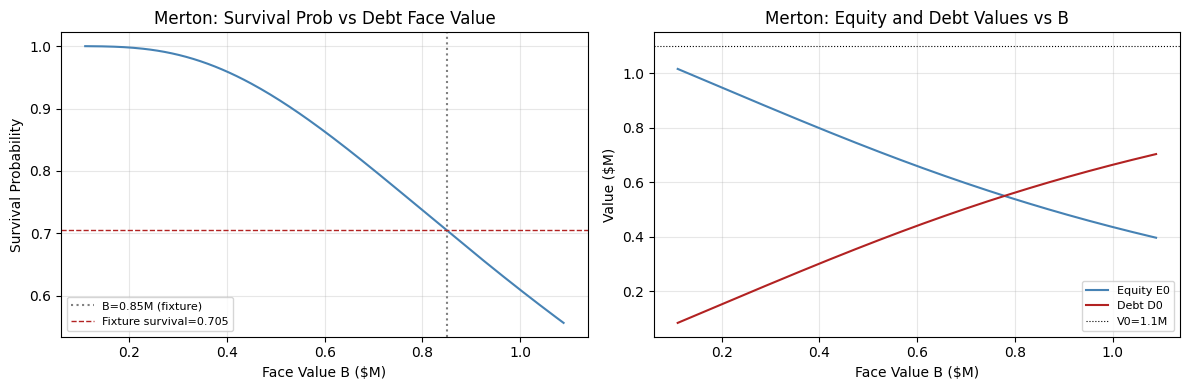

In [6]:
B_vals = np.linspace(0.10 * V0, 0.99 * V0, 200)

# Survival probability vs B
surv_vals  = [1 - merton_pd(V0, B_i, r, sigma, T) for B_i in B_vals]
# Equity and debt vs B
equity_v   = [merton_equity(V0, B_i, r, sigma, T) for B_i in B_vals]
debt_v     = [merton_debt(V0, B_i, r, sigma, T)   for B_i in B_vals]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(B_vals / 1e6, surv_vals, color='steelblue')
ax1.axvline(B / 1e6, color='gray', linestyle=':', label=f'B={B/1e6:.2f}M (fixture)')
ax1.axhline(1 - pd_Q, color='firebrick', linestyle='--', lw=1,
            label=f'Fixture survival={1-pd_Q:.3f}')
ax1.set_xlabel('Face Value B ($M)')
ax1.set_ylabel('Survival Probability')
ax1.set_title('Merton: Survival Prob vs Debt Face Value')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.plot(B_vals / 1e6, [e / 1e6 for e in equity_v], label='Equity E0', color='steelblue')
ax2.plot(B_vals / 1e6, [d / 1e6 for d in debt_v],   label='Debt D0',   color='firebrick')
ax2.axhline(V0 / 1e6, color='black', linestyle=':', lw=0.8, label=f'V0={V0/1e6:.1f}M')
ax2.set_xlabel('Face Value B ($M)')
ax2.set_ylabel('Value ($M)')
ax2.set_title('Merton: Equity and Debt Values vs B')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 7 - Q vs P Measure Comparison

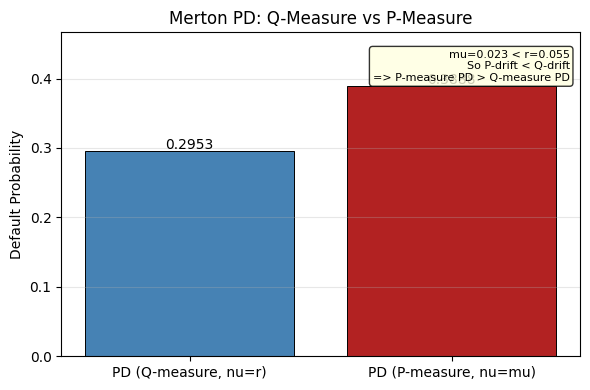

Under Merton:
  When mu < r: the real-world drift is lower than the risk-free rate.
  Under P, the firm value grows more slowly, so default is more likely.
  => PD_P = 0.3888 > PD_Q = 0.2953


In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['PD (Q-measure, nu=r)', 'PD (P-measure, nu=mu)']
vals   = [pd_Q, pd_P]
colors = ['steelblue', 'firebrick']
bars = ax.bar(labels, vals, color=colors, edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', fontsize=10)
ax.set_ylabel('Default Probability')
ax.set_title('Merton PD: Q-Measure vs P-Measure')
ax.set_ylim(0, max(vals) * 1.2)
ax.grid(axis='y', alpha=0.3)
ax.text(0.98, 0.85, f'mu={mu} < r={r}\nSo P-drift < Q-drift\n=> P-measure PD > Q-measure PD',
        transform=ax.transAxes, ha='right', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.show()

print('Under Merton:')
print(f'  When mu < r: the real-world drift is lower than the risk-free rate.')
print(f'  Under P, the firm value grows more slowly, so default is more likely.')
print(f'  => PD_P = {pd_P:.4f} > PD_Q = {pd_Q:.4f}')